# You need to do a pip install to run the code in this notebook!

Hi DIGIT 210! Dr. B here with some notes on pip installations to run this notebook: Go out to your shell, make sure you've activated your virtual environment on your folder hosting this notebook.

In your activated (.venv) at command line, run the following:

```shell
pip install scikit-learn
```

|<h2>Substack post:</h2>|<h1><a href="https://mikexcohen.substack.com/p/llm-breakdown-36-embeddings" target="_blank">LLM breakdown 3/6: Embeddings</a></h1>|
|-|:-:|
|<h2>Teacher:<h2>|<h1>Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h1>|

<br>

<i>Using the code without reading the post may lead to confusion or errors.</i>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import gridspec

from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

# pytorch libraries
import torch
import torch.nn.functional as F

# huggingface LLM
from transformers import GPT2Tokenizer

Unfortunately I still get errors after downloading all the correct pip installs. 

In [ ]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'figure.facecolor': '#171717',
    'figure.edgecolor': '#171717',
    'axes.facecolor':   '#171717',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

# Importing GPT2's embeddings matrix

In [3]:
# huggingface LLM
from transformers import AutoModelForCausalLM, GPT2Tokenizer

# GPT2 model and its tokenizer
model = AutoModelForCausalLM.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

Loading weights: 100%|█████████████████████| 148/148 [00:00<00:00, 1060.84it/s]


In [4]:
# toggle model into "evaluation" mode (turns off training-related operations)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [5]:
embeddings = model.transformer.wte.weight.detach()
embeddings.shape

torch.Size([50257, 768])

# Demo 1: Visualizing embeddings vectors

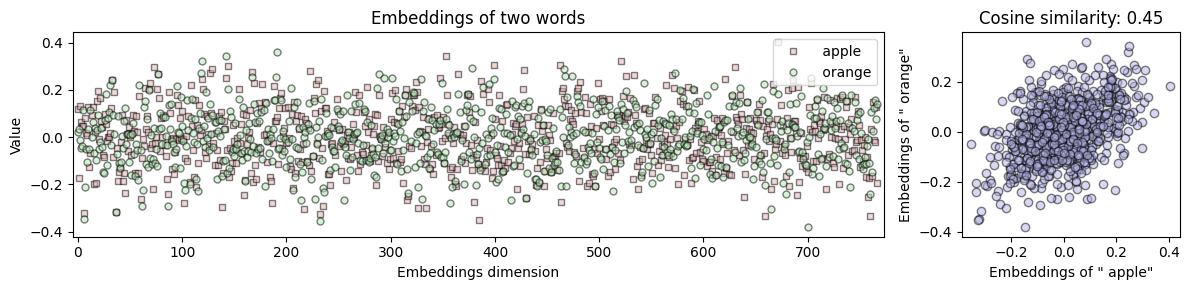

In [9]:
# two words (should be single-token)
word1 = ' apple'
word2 = ' orange'
# ebb: playing around with different words
# word1 = 'hello'
# word2 = 'world'

# get two token indices
token1 = tokenizer.encode(word1)
token2 = tokenizer.encode(word2)

# their embeddings vectors
emb1 = embeddings[token1].squeeze()
emb2 = embeddings[token2].squeeze()

# and their cosine similarity
cos_sim = F.cosine_similarity(emb1.unsqueeze(0), emb2)

# and plot
fig = plt.figure(figsize=(12,3))
gs = gridspec.GridSpec(1,4,figure=fig)
ax1 = fig.add_subplot(gs[:3])
ax2 = fig.add_subplot(gs[-1])

ax1.plot(emb1,'ks',markerfacecolor=[.9,.7,.7,.5],markersize=5,label=word1)
ax1.plot(emb2,'ko',markerfacecolor=[.7,.9,.7,.5],markersize=5,label=word2)

ax1.set(xlabel='Embeddings dimension',ylabel='Value',xlim=[-5,len(emb1)+5],title='Embeddings of two words')
ax1.legend()

ax2.plot(emb1,emb2,'ko',markerfacecolor=[.7,.7,.9,.5])
ax2.set(xlabel=f'Embeddings of "{word1}"',ylabel=f'Embeddings of "{word2}"',
        title=f'Cosine similarity: {cos_sim.item():.2f}')

plt.tight_layout()
plt.show()

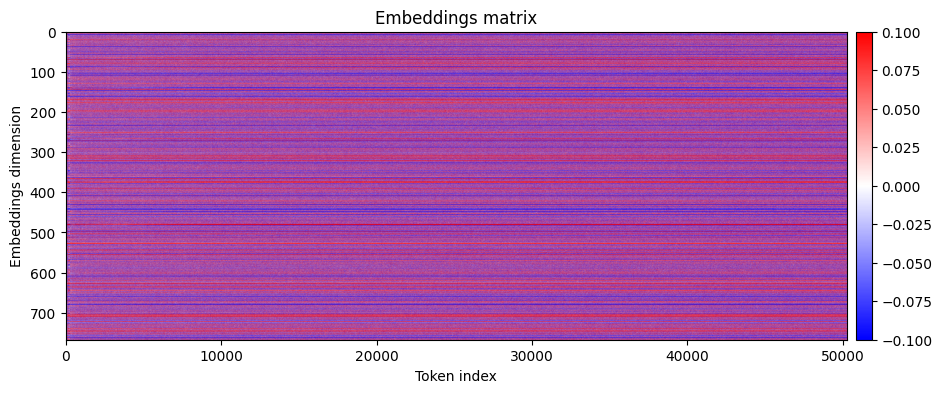

In [10]:
# the whole matrix
plt.figure(figsize=(12,4))
plt.imshow(embeddings.T,vmin=-.1,vmax=.1,aspect='auto',cmap='bwr')

plt.gca().set(xlabel='Token index',ylabel='Embeddings dimension',
              title='Embeddings matrix')

plt.colorbar(pad=.01)
plt.show()

This graph looks amazing, reminds me of a radiation graph. 

# Demo 2: Dimension-reducing embeddings

In [20]:
# extract the first N embeddings
nToks = 100
subEmbed = embeddings[:nToks,:]

# reduce to 2D with t-SNE
tsne = TSNE(n_components=2,perplexity=5)
#ebb/DIGIT 210: The TSNE perpexity value changes the number of nearest neighbors in the plot 
# basically, as he comments in his video, it changes how the plot is organized. try tinkering with the value.
tsne_result = tsne.fit_transform(subEmbed)

# the result is an Nx2 matrix (ebb: It will show that he's plotting 100 tokens in 2 dimensions.)
tsne_result.shape

(100, 2)

In [21]:
# plot the results
plt.figure(figsize=(7,6))

plt.scatter(tsne_result[:,0], tsne_result[:,1], color=[.7,.7,1],edgecolor='k')

# label words
yoffset = .02 * np.diff(plt.gca().get_ylim()) # shift words up by x%
for i in range(nToks):
  plt.text(tsne_result[i,0], tsne_result[i,1]+yoffset, tokenizer.decode([i]),  ha='center')

plt.gca().set(xlabel='TSNE dim 1',ylabel='TSNE dim 2',title='T-SNE visualization of embeddings')

plt.tight_layout()
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

Error in callback <function _draw_all_if_interactive at 0x000001775AA1A200> (for post_execute), with arguments args (),kwargs {}:


TypeError: only 0-dimensional arrays can be converted to Python scalars

TypeError: only 0-dimensional arrays can be converted to Python scalars

<Figure size 700x600 with 1 Axes>

**ebb to DIGIT 210:** Do you see how all the numbers cluster together? And the punctuation marks! Cap clusters w/ lower case... 
The diamonds are formatting and space characters like newlines, tabs, etc.
NOTICE, when you run the cell over and over without changing ANY parameters, the clusters change because they are randomly initiated!

# Demo 3: Manipulating embeddings vectors

In [13]:
# the main text
text = 'The capital of Germany is'

# source and target tokens
source = ' Germany'
target = ' Berlin'
distractor_source = ' France'
distractor_target = ' Paris'

# tokenize the texts and target words
tokens = tokenizer.encode(text,return_tensors='pt')
source_idx = tokenizer.encode(source)
target_idx = tokenizer.encode(target)

distractor_source_idx = tokenizer.encode(distractor_source)
distractor_target_idx = tokenizer.encode(distractor_target)

# index of the source word to replace
country_loc = torch.where(tokens[0]==tokenizer.encode(source)[0])[0].item()
country_loc
# This basically returns the position of the token in the text variable, counting from zero.

3

Python spit out a value of 3 here. 

In [19]:
with torch.no_grad():
  sm_logits = F.softmax(model(tokens).logits.detach(),dim=-1)

# probabilities of the two target tokens
target_logit = sm_logits[0,-1,target_idx]
distractor_target_logit = sm_logits[0,-1,distractor_target_idx]

print(f'           Target prob: {100*target_logit.item():.2f}%')
print(f'Distractor target prob: {100*distractor_target_logit.item():.2f}%')

Variable "output" has shape torch.Size([1, 5, 768])
Variable "mixed_vector" has shape torch.Size([1, 768])
           Target prob: 5.27%
Distractor target prob: 0.13%


In [17]:
pGermany = 1

# define and implant the hook function
def hook(module, input, output):

  # 1) print shape info
  print(f'Variable "output" has shape {output.shape}')

  # 2) create a new embeddings vector as some mixture of " Germany" and " France"
  mixed_vector =   pGermany  * embeddings[source_idx,:] + \
                (1-pGermany) * embeddings[distractor_source_idx,:]

  # 3) replace that vector
  print(f'Variable "mixed_vector" has shape {mixed_vector.shape}')
  output[0,country_loc,:] = mixed_vector

  # 4) and return the modified version
  return output

# 5) implant the hook function
hookHandle = model.transformer.wte.register_forward_hook(hook)

In [16]:
pGermany = 0

with torch.no_grad():
  sm_logits = F.softmax(model(tokens).logits.detach(),dim=-1)

target_logit = sm_logits[0,-1,target_idx]
distractor_target_logit = sm_logits[0,-1,distractor_target_idx]

print('')
print(f'           Target prob: {100*target_logit.item():.2f}%')
print(f'Distractor target prob: {100*distractor_target_logit.item():.2f}%')


           Target prob: 5.27%
Distractor target prob: 0.13%


This is interesting. My Jupyter actually ran the program. It spit out Target Prob: 5.27% and Distractor Target Prob: 0.13%

In [15]:
# Now for the experiment!

# mixture values
mixtures = np.linspace(0,1,17)

# initialize
target_prob = np.zeros((len(mixtures),2))

for i in range(len(mixtures)):

  # set the mixing parameter (globally defined and read by the hook function)
  pGermany = mixtures[i]

  # run the tokens through the model
  with torch.no_grad():
    sm_logits = F.softmax(model(tokens).logits.detach(),dim=-1)

  # get the output logits for the targets
  target_prob[i,0] = 100*sm_logits[0,-1,target_idx]
  target_prob[i,1] = 100*sm_logits[0,-1,distractor_target_idx]


# remove the hook
hookHandle.remove()

NameError: name 'hookHandle' is not defined

In [14]:
plt.figure(figsize=(8,4))

plt.plot(mixtures,target_prob[:,0],'ko-',markerfacecolor=[.7,.9,.7],markersize=10,label='Berlin')
plt.plot(mixtures,target_prob[:,1],'ks-',markerfacecolor=[.7,.7,.9],markersize=10,label='Paris')

plt.gca().set(xlabel='Manipulated vector proportion',ylabel='Softmax probability (%)',title='$\\sigma$(logits) to "The capital of [Germany/France] is"',
              xticks=[0,.5,1],xticklabels=['100%\n"France"','50/50','100%\n"Germany"'])
plt.legend(fontsize=16)

plt.show()

NameError: name 'mixtures' is not defined

<Figure size 800x400 with 0 Axes>

**ebb to DIGIT 210:** Notice that the crossover between Berlin and Paris doesn't occur at 50/50, but more at like 40% Berlin and 60% Paris! 
Cohen explains this as a "bias" toward " Berlin" in this GPT2 model, probably to do with that word appearing more frequently in GPT2's training data.